Running BIDMC data ---------------------------


JSONDecodeError: Expecting ',' delimiter: line 21 column 7 (char 533)

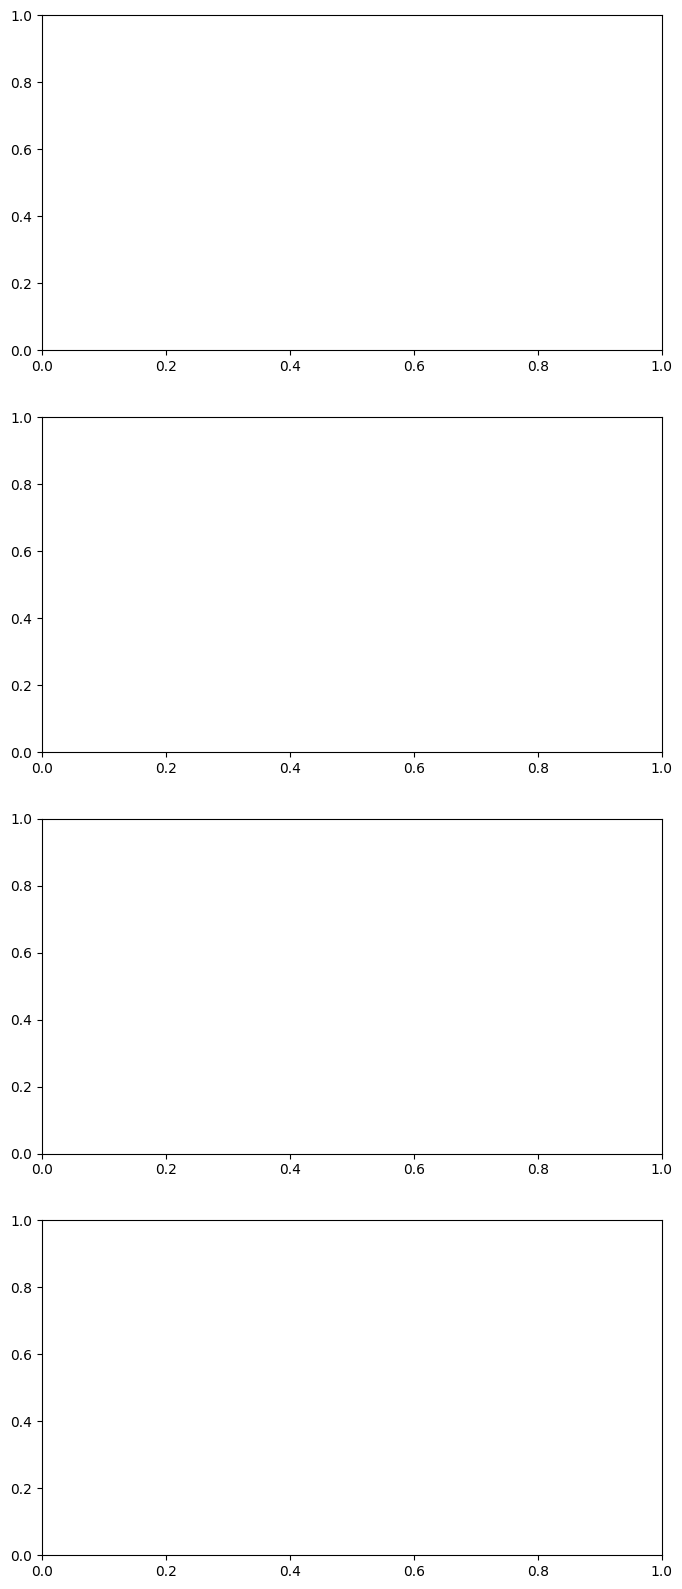

In [4]:
from main import main
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import copy
from pathlib import Path 
import os

centers = ['BIDMC', 'Stanford', 'BCH', 'CHLA']
centerlabel = {
    'BIDMC': 'AE', 
    'Stanford': 'AW', 
    'BCH': 'PE', 
    'CHLA': 'PW'
}
# mode = 'all_combinations'  # 'flagged_vs_unflagged', 'all_combinations'
mode = 'flagged_vs_unflagged'

frames = []
fig, axes = plt.subplots(4,1, figsize=(8, 20))

for row,(ax,center) in enumerate(zip(axes,centers)):
    # Call main function with correct parameters and pass ax through plot_kwargs
    # TODO: add option to load from saved
    df = main(
        path_base=Path('/Volumes/chip-lacava/Groups/CHLA-ED/data_binarized_ESI'),
        center=center,
        mode=mode,  # or 'all_combinations'
        ax=ax  # Pass the axis through plot_kwargs
    )

    # Plotting customization code
    ax.tick_params(axis='y', which='both', pad=275)
    ax.set_title(f'Hospital: {centerlabel[center]}', fontweight='bold', loc='right', fontsize=12, y=1.0, pad=-15)
    ax.set_xlim(0.6, 1.4)
    if row == 0: 
        # makes y column labels appear
        ax.set_ylim(top=16)
    # ax.text(0,0, centerlabel[center],fontsize=12,rotation=90)
    # plt.text(0,0, 'test',fontsize=12,rotation=90)
    if row < len(axes)-1:
        ax.set_xlabel('')
        ax.tick_params(axis='x', which='both', bottom=False,labelbottom=False)
    else:
        print(ax.get_xticklabels())
        ax.set_xlabel('Odds Ratio vs White, Triage Assignment 2')

    # Label customization
    shade = False
    labels = ax.get_yticklabels()
    for label in labels:
        if 'Both HB' in label._text:
            print(label.get_text())
            label.set_text(label._text.replace('Both HB levels','All           '))
    ax.set_yticklabels(labels)

    # Styling
    for label in ax.get_yticklabels():
        plt.setp(label,fontsize=10,linespacing=1.,va='center') #,edgecolor='w') 
        if label.get_fontweight() == 'bold':
            shade=True
            continue
        fc = 'whitesmoke' if shade else 'w'
        label._bbox_patch = FancyBboxPatch((0, 0), width=1000, height=5,fc=fc, ec='lightgray', boxstyle='round') 
        if shade:
            plt.setp(label, backgroundcolor='whitesmoke')
        shade= not shade
    frames.append(df)
    color_wheel = ['k','k','k','r','r','r','orange','orange','orange']

    # Color customization
    color_wheel = [
        'y',
        'r',
        'darkslategray',
        'k',
        'y',
        'r',
        'darkslategray',
        'k',
        'y',
        'r',
        'darkslategray',
        'k',
        'y',
        'r',
        'darkslategray'
    ]
    
    for collection in ax.collections:
        cw = copy.copy(color_wheel)
        if hasattr(collection,'set_facecolors'):
            collection.set_facecolors(cw)
        if hasattr(collection,'set_edgecolors'):
            collection.set_edgecolors(color_wheel)

fig.subplots_adjust(hspace=0.05)

# Save figure
os.makedirs('figures', exist_ok=True)
fig.savefig(f'figures/or_all_{mode}.pdf', bbox_inches='tight')
print(f"Figure saved to: figures/or_all_{mode}.pdf")
plt.show()

# ax = axes[0]
# ax.get_yticklabels()
# y = ax.get_yticklabels()[1]
# vars(ax)
# print(y._bbox_patch)
# vars(ax)
# ax.get_ylim()
# print(len(ax._children))
# print(len(ax.get_yticklabels()))

# vars(ax._children[0]._marker)
# dir(ax.collections[0])
# collection = ax.collections[0]

# dir(collection)